In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error,mean_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()

print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)

print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

In [2]:
ts = df["Sown_Extent_Total"]
ts.tail()

Date
2023-04-01    505076
2023-09-01    806673
2024-04-01    481316
2024-09-01    800463
2025-04-01    541422
Name: Sown_Extent_Total, dtype: int64

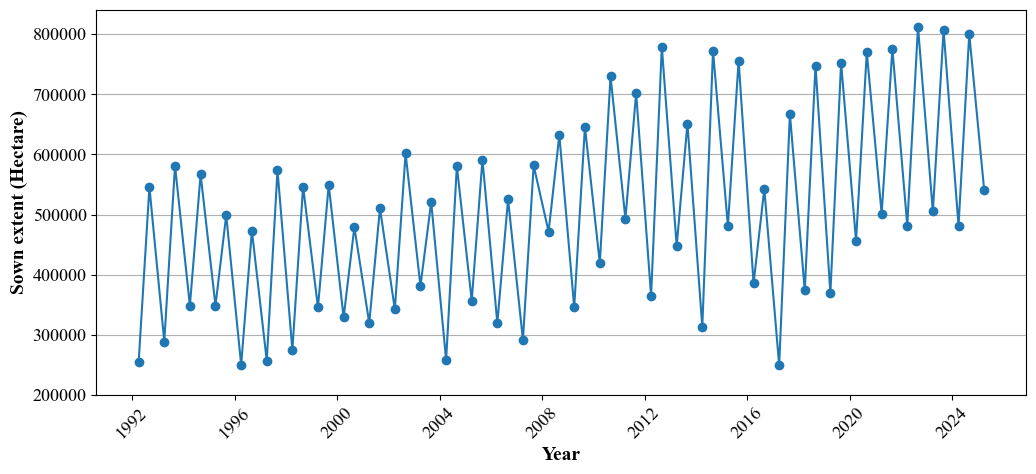

In [3]:
plt.figure(figsize=(12,5))
plt.plot(ts,marker="o",linewidth=1.5)

# plt.title("Sown Extent Time Series")
plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Sown extent (Hectare)",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.grid(axis='y')
plt.ylim(200000,)
plt.xticks(rotation=45)

plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

In [4]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [5]:
from statsmodels.tsa.stattools import adfuller, kpss
def adf_test(series, label="Series"):
    result = adfuller(series, autolag="AIC")
    p = result[1]
    print(f"\n  ADF Test [{label}]")
    print(f"    Statistic : {result[0]:.4f}")
    print(f"    p-value   : {p:.4f}")
    print(f"    Critical 5%: {result[4]['5%']:.4f}")
    print(f"    → {'✅ STATIONARY' if p < 0.05 else '❌ NON-STATIONARY — differencing needed'}")
    return p

adf_test(ts, "Original")


  ADF Test [Original]
    Statistic : -0.6556
    p-value   : 0.8579
    Critical 5%: -2.9147
    → ❌ NON-STATIONARY — differencing needed


np.float64(0.8579254016459419)

In [6]:
ts_seasonal = ts.diff(2).dropna()

adf_test(ts_seasonal, "Seasonal Difference")


  ADF Test [Seasonal Difference]
    Statistic : -2.5906
    p-value   : 0.0950
    Critical 5%: -2.9147
    → ❌ NON-STATIONARY — differencing needed


np.float64(0.09495892733958589)

In [12]:
ts_diff1 = ts_seasonal.diff().dropna()

adf_test(ts_diff1,"Seasonal+differenced" )


  ADF Test [Seasonal+differenced]
    Statistic : -6.3888
    p-value   : 0.0000
    Critical 5%: -2.9147
    → ✅ STATIONARY


np.float64(2.1312492268462782e-08)

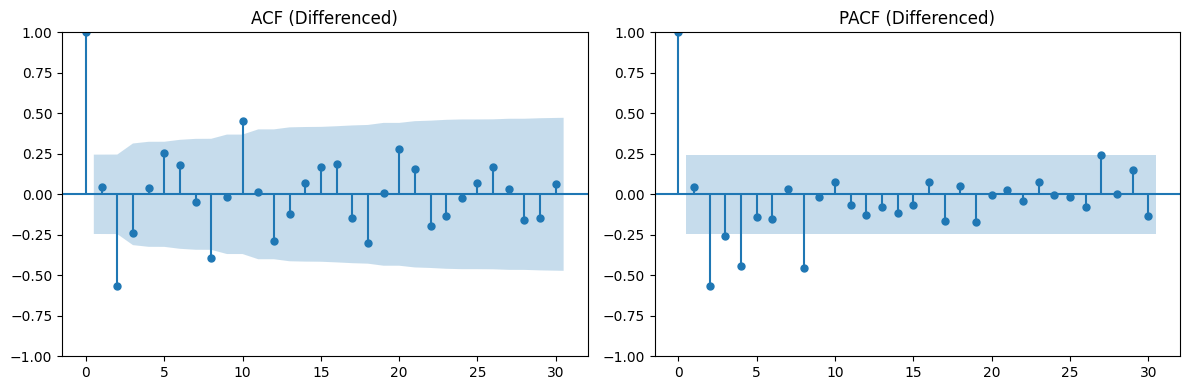

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(ts_diff1, lags=30, ax=axes[0])
axes[0].set_title("ACF (Differenced)")

plot_pacf(ts_diff1, lags=30, ax=axes[1], method='ywm')
axes[1].set_title("PACF (Differenced)")

plt.tight_layout()
plt.show()

In [6]:
# Automatically Find Best SARIMA Model
auto_model = auto_arima(train, 
                   seasonal=True,
                   test='adf', 
                   m=2, 
                   stepwise=True, 
                   suppress_warnings=True,
                   trace=True)

print(auto_model)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[2] intercept   : AIC=1299.891, Time=0.13 sec
 ARIMA(0,0,0)(0,1,0)[2] intercept   : AIC=1307.910, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[2] intercept   : AIC=1298.611, Time=0.02 sec
 ARIMA(0,0,1)(0,1,1)[2] intercept   : AIC=1296.373, Time=0.03 sec
 ARIMA(0,0,0)(0,1,0)[2]             : AIC=1306.100, Time=0.01 sec
 ARIMA(0,0,1)(0,1,0)[2] intercept   : AIC=1301.908, Time=0.02 sec
 ARIMA(0,0,1)(1,1,1)[2] intercept   : AIC=1298.205, Time=0.06 sec
 ARIMA(0,0,1)(0,1,2)[2] intercept   : AIC=1298.220, Time=0.08 sec
 ARIMA(0,0,1)(1,1,0)[2] intercept   : AIC=1297.839, Time=0.03 sec
 ARIMA(0,0,1)(1,1,2)[2] intercept   : AIC=1298.442, Time=0.15 sec
 ARIMA(0,0,0)(0,1,1)[2] intercept   : AIC=1303.447, Time=0.02 sec
 ARIMA(1,0,1)(0,1,1)[2] intercept   : AIC=1297.627, Time=0.08 sec
 ARIMA(1,0,0)(0,1,1)[2] intercept   : AIC=1295.180, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[2] intercept   : AIC=1306.679, Time=0.03 sec
 ARIMA(1,0,0)(1,1,1)[2] intercept

In [7]:

# Generate a summary of the best model found
print(auto_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   53
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 2)   Log Likelihood                -644.010
Date:                             Tue, 02 Jun 2026   AIC                           1294.019
Time:                                     12:30:19   BIC                           1299.815
Sample:                                          0   HQIC                          1296.234
                                              - 53                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4100      0.182      2.253      0.024       0.053       0.767
ma.S.L2       -0.5525      

In [8]:
print(auto_model.fit(train))

 ARIMA(1,0,0)(0,1,1)[2]          


In [9]:
forecast = auto_model.predict(n_periods=len(test))
forecast

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    674539.272137
54    359052.232159
55    668508.367634
56    356579.770523
57    667494.744132
58    356164.220049
59    667324.382853
60    356094.377835
61    667295.749968
62    356082.639345
63    667290.937594
64    356080.666439
65    667290.128771
66    356080.334849
dtype: float64

In [10]:
dates = test.index
forecast_df = pd.DataFrame(index=dates)

forecast_df['Prediction'] = forecast.values.round(2)

# Season
forecast_df['Season'] = np.where(
    dates.month == 4,
    'Yala',
    'Maha'
)

# Agricultural year
forecast_df['Year'] = np.where(
    dates.month == 4,          # Yala starts in April
    dates.year,
    dates.year + 1            # Maha starts in September, assigned to next year
)

forecast_df = forecast_df[['Prediction', 'Year', 'Season']]

forecast_df

,Prediction,Year,Season
Date,,,
2018-09-01,674539.27,2019,Maha
2019-04-01,359052.23,2019,Yala
2019-09-01,668508.37,2020,Maha
2020-04-01,356579.77,2020,Yala
2020-09-01,667494.74,2021,Maha
2021-04-01,356164.22,2021,Yala
2021-09-01,667324.38,2022,Maha
2022-04-01,356094.38,2022,Yala
2022-09-01,667295.75,2023,Maha


In [11]:
forecast_df = pd.DataFrame(forecast.values.round(2), index= test.index, columns=['Prediction'])
forecast_df

,Prediction
Date,
2018-09-01,674539.27
2019-04-01,359052.23
2019-09-01,668508.37
2020-04-01,356579.77
2020-09-01,667494.74
2021-04-01,356164.22
2021-09-01,667324.38
2022-04-01,356094.38
2022-09-01,667295.75


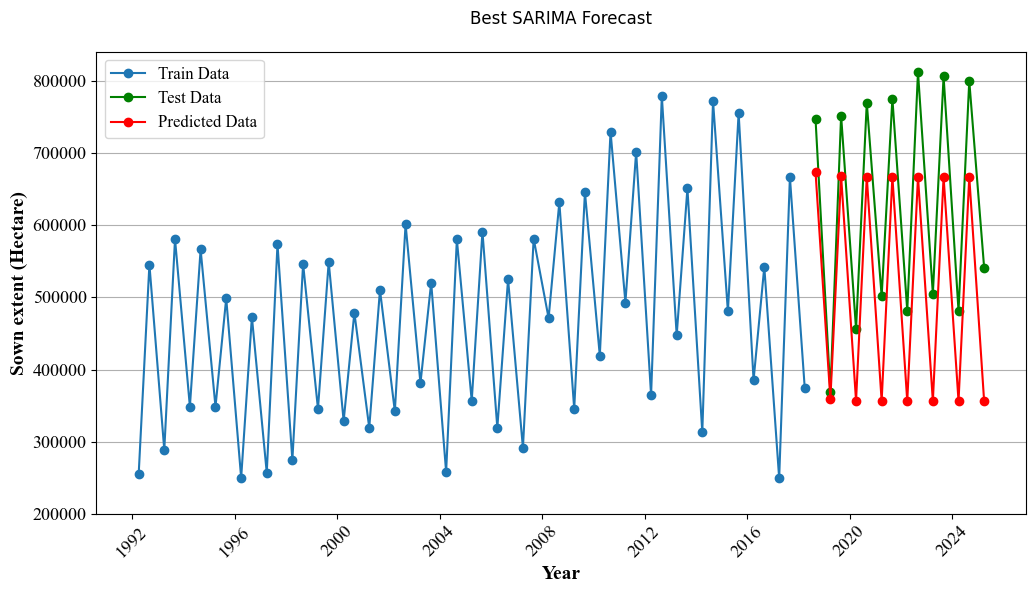

In [12]:
#Plot Forecast
plt.figure(figsize=(12,6))


plt.plot(train.index, train, label="Train Data",marker="o",linewidth=1.5)
plt.plot(test.index, test, label="Test Data", color="green",marker="o",linewidth=1.5)
plt.plot(test.index, forecast, label="Predicted Data", color="red",marker="o",linewidth=1.5)

plt.legend(prop={'size': 12, 'family':'Times New Roman'}  )

plt.title("Best SARIMA Forecast",pad=20)

plt.ylim(200000,)


plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Sown extent (Hectare)",fontsize=14,fontweight='bold',fontname='Times New Roman')

plt.grid(axis='y')
plt.xticks(rotation=45)

plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

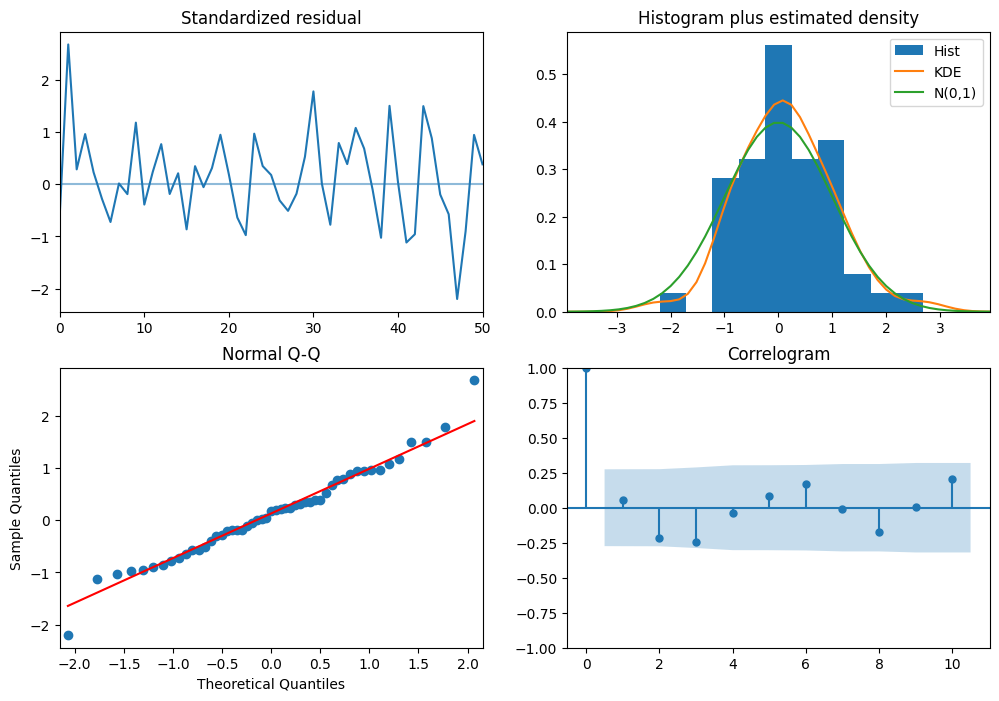

In [13]:
# Diagnostic plots
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [14]:
#Evaluate Model
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 123103.06
MAPE : 19.24
MAE : 116163.01
R²   : 0.3866
